In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from simulator import simulate

In [18]:
# Load observed data from the 'data' directory
obs_infected = pd.read_csv('data/infected_timeseries.csv')
obs_rewiring = pd.read_csv('data/rewiring_timeseries.csv')
obs_degrees = pd.read_csv('data/final_degree_histograms.csv')

In [19]:
peaks_per_rep = obs_infected.groupby('replicate_id')['infected_fraction'].max()
rewires_per_rep = obs_rewiring.groupby('replicate_id')['rewire_count'].sum()

N_agents = 200
obs_degrees['deg_x_count'] = obs_degrees['degree'] * obs_degrees['count']
obs_degrees['deg2_x_count'] = (obs_degrees['degree']**2) * obs_degrees['count']
mean_deg_per_rep = obs_degrees.groupby('replicate_id')['deg_x_count'].sum() / N_agents
var_deg_per_rep = obs_degrees.groupby('replicate_id')['deg2_x_count'].sum() / N_agents - mean_deg_per_rep**2

target_peak = peaks_per_rep.mean()
std_peak = peaks_per_rep.std()

target_rewires = rewires_per_rep.mean()
std_rewires = rewires_per_rep.std()

target_var_deg = var_deg_per_rep.mean()
std_var_deg = var_deg_per_rep.std()

print("=== Targets & Normalization Weights (Std) ===")
print(f"Peak Infected : Mean = {target_peak:.3f}, Std = {std_peak:.3f}")
print(f"Total Rewires : Mean = {target_rewires:.1f}, Std = {std_rewires:.1f}")
print(f"Degree Variance: Mean = {target_var_deg:.2f}, Std = {std_var_deg:.2f}")

=== Targets & Normalization Weights (Std) ===
Peak Infected : Mean = 0.657, Std = 0.043
Total Rewires : Mean = 545.1, Std = 38.6
Degree Variance: Mean = 10.34, Std = 1.24


In [21]:
N_particles = 100_000
tolerance = 3.0

accepted_params = []
rng = np.random.default_rng(100)
degrees_arr = np.arange(31)

print("Starting ABC with Normalized Euclidean Distance...")

for i in range(N_particles):
    beta = rng.uniform(0.05, 0.50)
    gamma = rng.uniform(0.02, 0.20)
    rho = rng.uniform(0.0, 0.8)
    
    sim_infected, sim_rewires, sim_degrees = simulate(beta=beta, gamma=gamma, rho=rho, rng=rng)
    
    sim_peak = np.max(sim_infected)
    sim_rewires_tot = np.sum(sim_rewires)
    sim_mean_deg = np.sum(degrees_arr * sim_degrees) / N_agents
    sim_var_deg = np.sum((degrees_arr**2) * sim_degrees) / N_agents - sim_mean_deg**2
    
    norm_diff_peak = (sim_peak - target_peak) / std_peak
    norm_diff_rewires = (sim_rewires_tot - target_rewires) / std_rewires
    norm_diff_deg = (sim_var_deg - target_var_deg) / std_var_deg
    
    distance = np.sqrt(norm_diff_peak**2 + norm_diff_rewires**2 + norm_diff_deg**2)
    
    if distance < tolerance:
        accepted_params.append({'beta': beta, 'gamma': gamma, 'rho': rho})
        
    if (i + 1) % 1000 == 0:
        print(f"Processed {i + 1}/{N_particles}... Current accepted: {len(accepted_params)}")

Starting ABC with Normalized Euclidean Distance...
Processed 1000/100000... Current accepted: 55
Processed 2000/100000... Current accepted: 120
Processed 3000/100000... Current accepted: 187
Processed 4000/100000... Current accepted: 235
Processed 5000/100000... Current accepted: 287
Processed 6000/100000... Current accepted: 353
Processed 7000/100000... Current accepted: 411
Processed 8000/100000... Current accepted: 467
Processed 9000/100000... Current accepted: 530
Processed 10000/100000... Current accepted: 585
Processed 11000/100000... Current accepted: 656
Processed 12000/100000... Current accepted: 713
Processed 13000/100000... Current accepted: 777
Processed 14000/100000... Current accepted: 839
Processed 15000/100000... Current accepted: 910
Processed 16000/100000... Current accepted: 975
Processed 17000/100000... Current accepted: 1035
Processed 18000/100000... Current accepted: 1096
Processed 19000/100000... Current accepted: 1157
Processed 20000/100000... Current accepted: 


Total accepted particles: 6139


,beta,gamma,rho
0,0.158970,0.060353,0.317566
1,0.331859,0.091355,0.521820
2,0.238348,0.117345,0.335078
3,0.455428,0.107675,0.584223
4,0.401077,0.157226,0.544669


Saved histograms to: plots/posterior_histograms_s3.pdf


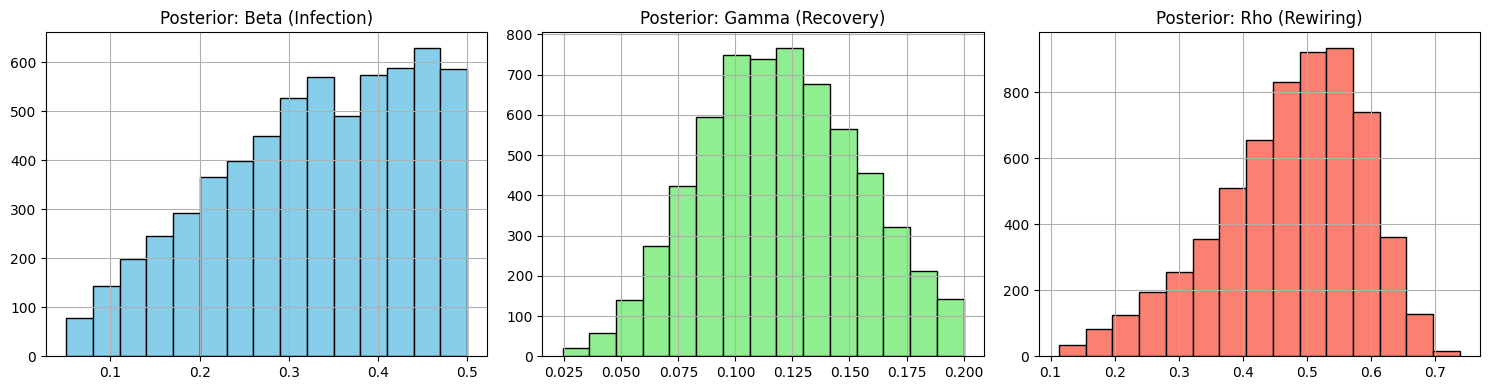

Generating Pairwise Plots...
Saved pairplot to: plots/posterior_pairplot_s3.pdf


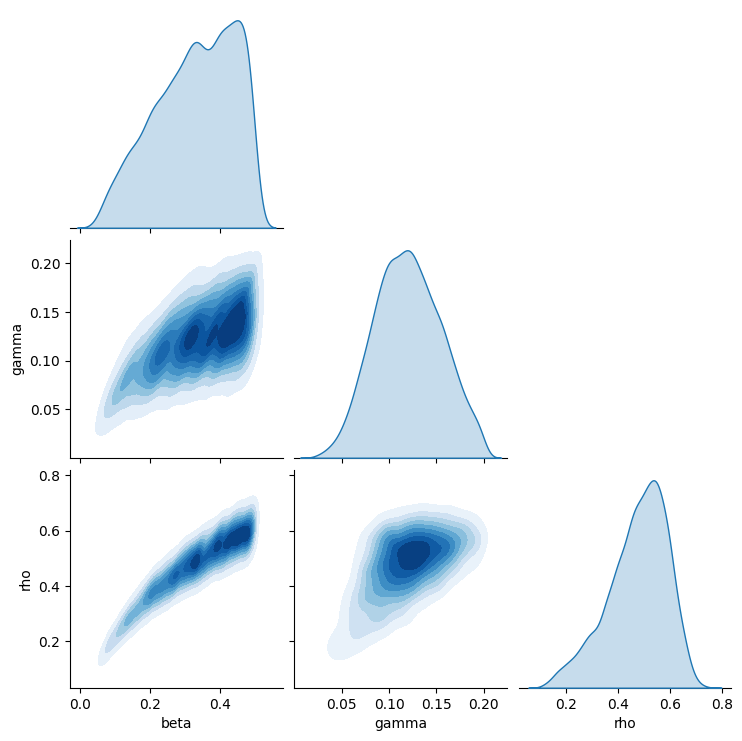

In [22]:
df_posterior = pd.DataFrame(accepted_params)
print(f"\nTotal accepted particles: {len(df_posterior)}")

bins = 25

if len(df_posterior) > 0:
    display(df_posterior.head())
    
    # ---------------------------------------------------------
    # 1. Marginal Histograms 
    # ---------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    df_posterior['beta'].hist(ax=axes[0], bins=15, color='skyblue', edgecolor='black')
    axes[0].set_title('Posterior: Beta (Infection)')
    
    df_posterior['gamma'].hist(ax=axes[1], bins=15, color='lightgreen', edgecolor='black')
    axes[1].set_title('Posterior: Gamma (Recovery)')
    
    df_posterior['rho'].hist(ax=axes[2], bins=15, color='salmon', edgecolor='black')
    axes[2].set_title('Posterior: Rho (Rewiring)')
    
    plt.tight_layout()
    
    hist_path = 'plots/posterior_histograms_s3.pdf'
    plt.savefig(hist_path, format='pdf', bbox_inches='tight')
    print(f"Saved histograms to: {hist_path}")
    
    plt.show()
    
    # ---------------------------------------------------------
    # 2. Pairwise plots
    # ---------------------------------------------------------
    print("Generating Pairwise Plots...")
    g = sns.pairplot(df_posterior, kind='kde', corner=True, 
                    plot_kws={'fill': True, 'cmap': 'Blues'}) 
    
    pairplot_path = 'plots/posterior_pairplot_s3.pdf'
    g.savefig(pairplot_path, format='pdf', bbox_inches='tight')
    print(f"Saved pairplot to: {pairplot_path}")
    
    plt.show()
    
else:
    print("No particles accepted. Try increasing 'tolerance'.")